In [13]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association  # Cramer's V

In [14]:
import os
os.chdir("..")
print(os.getcwd())


c:\Users\mocim\OneDrive\Desktop\Lessons


In [15]:
df = pd.read_csv(r"C:\Users\mocim\OneDrive\Desktop\Lessons\Week 5_EDA_Inferencial_Statistics\amz_uk_price_prediction_dataset.csv")
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


### PART 1.Objective: Understand the relationship between product categories and their best-seller status.

### 1. Crosstab Analysis:

-  Create a crosstab between the product category and the isBestSeller status.

-  Are there categories where being a best-seller is more prevalent?

Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.


In [16]:
crosstab_cat_best = pd.crosstab(df["category"], df["isBestSeller"], normalize="index")
crosstab_cat_best.sort_values(True, ascending= False)

isBestSeller,False,True
category,,
Grocery,0.941865,0.058135
Smart Home Security & Lighting,0.942308,0.057692
Health & Personal Care,0.942314,0.057686
Mobile Phone Accessories,0.957529,0.042471
Power & Hand Tools,0.964661,0.035339
...,...,...
"CD, Disc & Tape Players",1.000000,0.000000
General Music-Making Accessories,1.000000,0.000000
Snowboard Boots,1.000000,0.000000


The crosstab shows that being BestSeller is not prevanlent in certain categories. 

### 2. Statistical Tests:

- Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
- Compute Cramér's V to understand the strength of association between best-seller status and category.

In [17]:
crosstab_cat_best_2 = pd.crosstab(df["category"], df["isBestSeller"]) 

In [18]:
chi2_contingency(crosstab_cat_best_2)

Chi2ContingencyResult(statistic=np.float64(36540.20270061387), pvalue=np.float64(0.0), dof=295, expected_freq=array([[2.47190130e+02, 8.09870149e-01],
       [4.05371878e+03, 1.32812173e+01],
       [2.49183599e+02, 8.16401360e-01],
       [1.69145827e+03, 5.54173243e+00],
       [2.53170536e+02, 8.29463782e-01],
       [8.50214439e+03, 2.78556144e+01],
       [1.06650580e+02, 3.49419782e-01],
       [2.57157474e+02, 8.42526204e-01],
       [9.51781673e+03, 3.11832664e+01],
       [1.50008526e+04, 4.91473619e+01],
       [9.32544700e+03, 3.05530045e+01],
       [2.38219520e+02, 7.80479700e-01],
       [3.22941944e+03, 1.05805616e+01],
       [9.44704859e+03, 3.09514084e+01],
       [6.68808779e+03, 2.19122125e+01],
       [5.26275760e+02, 1.72423967e+00],
       [1.90296531e+04, 6.23469391e+01],
       [2.77191835e+03, 9.08164873e+00],
       [2.53170536e+02, 8.29463782e-01],
       [4.04674164e+02, 1.32583581e+00],
       [1.92489346e+04, 6.30653723e+01],
       [3.10482764e+03, 1.017

In [19]:
association(crosstab_cat_best_2, method="cramer") 

# Low cramer's V, suggesting week relation between both variables. 

0.1222829439760564

### 3. Visualizations:

- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

<Axes: xlabel='category'>

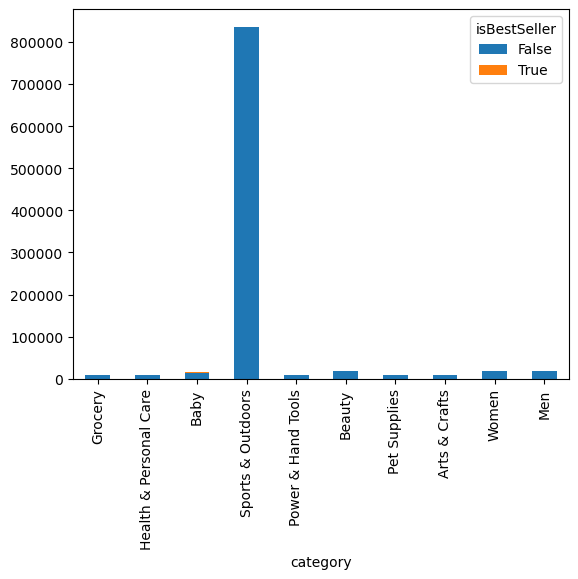

In [20]:
top10 = crosstab_cat_best_2.sort_values(by=True, ascending = False).head(10)
top10.plot(kind="bar", stacked=True)

<Axes: xlabel='category'>

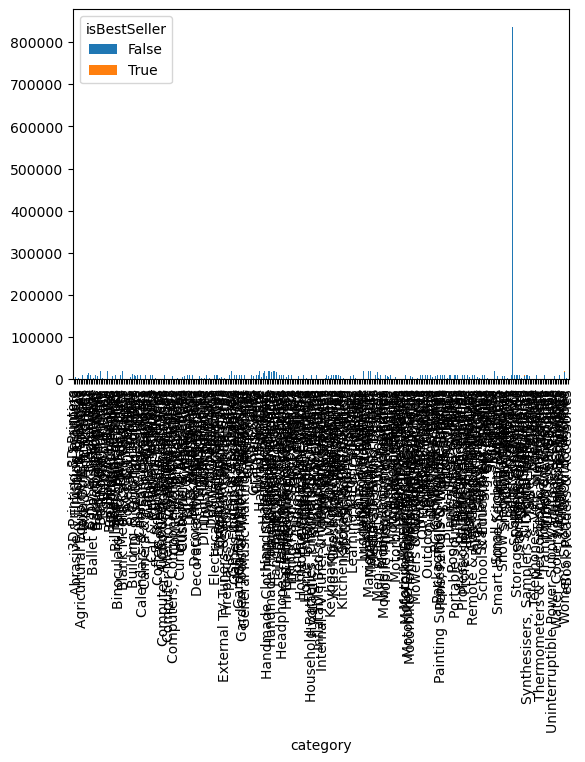

In [21]:
crosstab_cat_best_2.plot(kind="bar", stacked=True)

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

### Objective: Investigate how different product categories influence product prices.

1. Preliminary Step: Remove outliers in product prices.

- For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.

Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.




In [22]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [23]:
IQR = df["price"].quantile(0.75) - df["price"].quantile(0.25)
IQR

np.float64(36.0)

In [24]:
upper_bound = df["price"].quantile(0.75) + (1.5*IQR)
upper_bound

np.float64(99.99000000000001)

In [25]:
lower_bound = df["price"].quantile(0.25) - (1.5*IQR)
lower_bound

np.float64(-44.01)

In [26]:
outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)] 

# Then can do: df = df.drop(outliers.index)

In [27]:
# Keep with non outlier data 

df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]

2. Violin Plots:

- Use a violin plot to visualize the distribution of price across different product categories. Filter out the top 20 categories based on count for better visualization.
- Which product category tends to have the highest median price? Don't filter here by top categories.

In [28]:
top_20 = df["category"].value_counts().head(20).index
top_20

Index(['Sports & Outdoors', 'Beauty', 'Bath & Body',
       'Manicure & Pedicure Products',
       'Handmade Clothing, Shoes & Accessories', 'Make-up', 'Skin Care',
       'Hair Care', 'Birthday Gifts', 'Handmade Gifts', 'Handmade Home Décor',
       'Luggage and travel gear', 'Women', 'Fragrances',
       'Handmade Kitchen & Dining', 'Handmade Artwork',
       'Handmade Home & Kitchen Products', 'Handmade Jewellery', 'Men',
       'Baby'],
      dtype='object', name='category')

In [29]:
df_top_20 = df[df["category"].isin(top_20)]
df_top_20

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
19513,21072,B09477KHQ3,"Personalised Birthday Print Gift ""THE YEAR YOU...",4.5,763,7.99,False,900,Handmade Home & Kitchen Products
19514,21073,B0BSRFQYG8,Wax Melts 4 Bars | Build Your Own Box (Choose ...,3.9,117,6.49,True,800,Handmade Home & Kitchen Products
19515,21074,B09N9GVHV9,"Personalised Birthday Print Gift ""ON THE DAY/Y...",4.6,1155,8.99,True,600,Handmade Home & Kitchen Products
19516,21075,B0BRYGV7PQ,Fresh Wax Melts - Laundry Type Wax Melts - Str...,4.5,56,4.99,True,500,Handmade Home & Kitchen Products
19517,21076,B0B1JHB28R,Manta Makes Work Leaving Gifts | I Used to Wor...,4.7,261,9.95,True,400,Handmade Home & Kitchen Products
...,...,...,...,...,...,...,...,...,...
2429088,2806950,B0045I6SHW,Cannondale Men's Bibshort Dart Team Bike Shorts,0.0,0,99.67,False,0,Sports & Outdoors
2429089,2806951,B0045I6NZY,Cannondale Men's Baggy Fitness Bike Shorts,0.0,0,20.62,False,0,Sports & Outdoors
2429090,2806952,B003BLON3A,Pearl iZUMi Men's Phase Splice Knicker,4.3,3,59.86,False,0,Sports & Outdoors
2437153,2818782,B091HG57TP,Goodstoworld Boys Girls Tracksuit Bottoms 3D S...,4.2,554,14.99,False,0,Sports & Outdoors


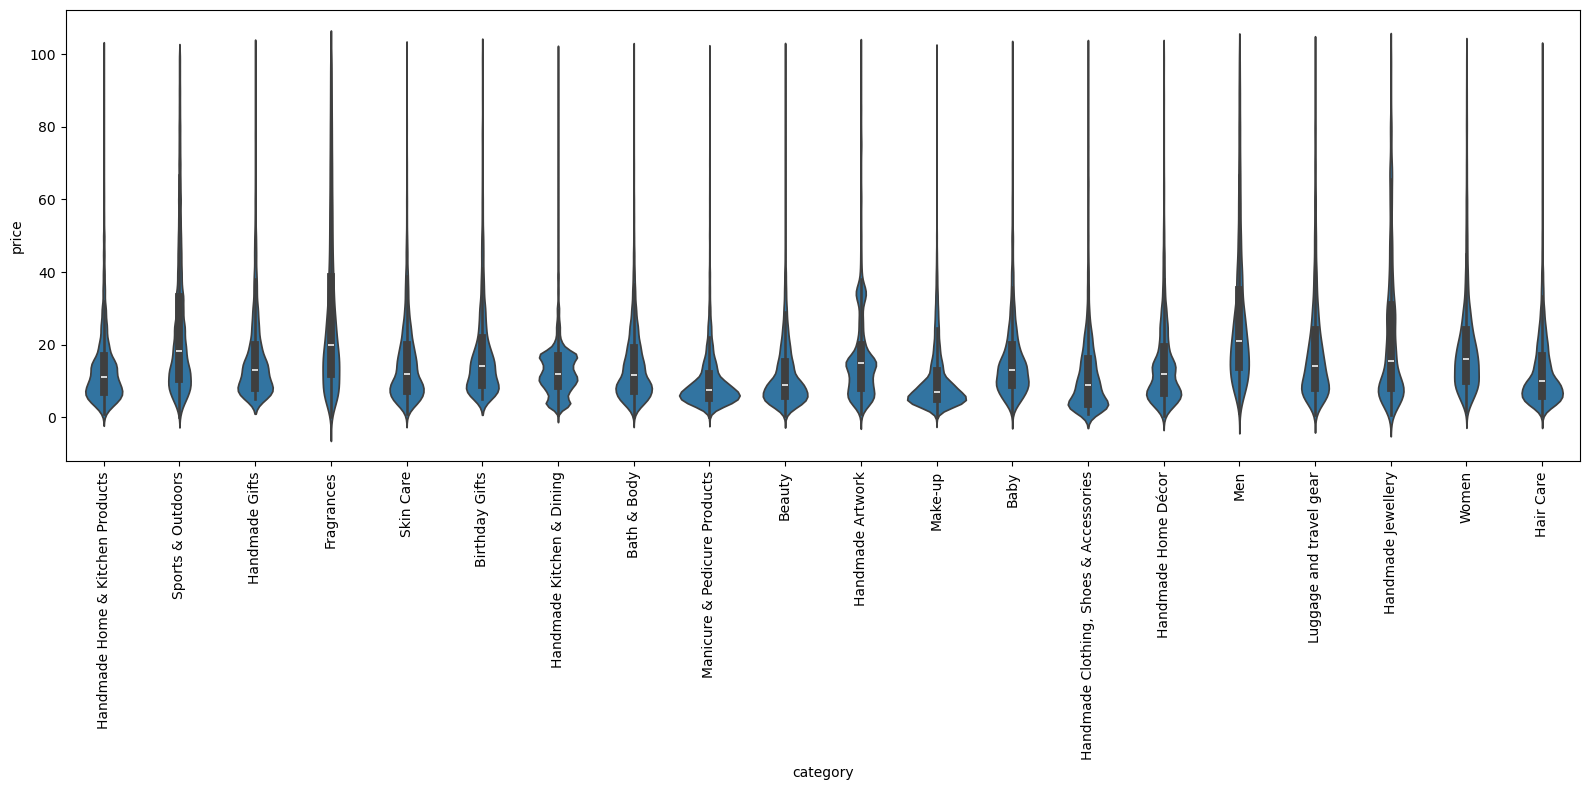

In [ ]:
plt.figure(figsize=(16,8))
sns.violinplot(data=df_top_20, x="category", y="price")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Men category has a higher median price

In [32]:
print(df.shape)
print(df_top_20.shape)

(2115963, 9)
(1033008, 9)


3. Bar Charts:

- Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
- Which product category commands the highest average price? Don't filter here by top categories.

In [43]:
count = pd.crosstab(index=df["category"], columns = "count").sort_values(by="count", ascending =False).head(10)
count

col_0,count
category,
Sports & Outdoors,694092
Beauty,19233
Bath & Body,19050
Manicure & Pedicure Products,18904
"Handmade Clothing, Shoes & Accessories",18811
Make-up,18718
Skin Care,18686
Hair Care,18625
Birthday Gifts,18398


In [49]:
top_10_avg = df[df["category"].isin(count.index)].groupby("category")[["price"]].mean()

In [50]:
top_10_avg

,price
category,
Bath & Body,14.678683
Beauty,12.523480
Birthday Gifts,18.600195
Hair Care,13.461408
"Handmade Clothing, Shoes & Accessories",12.958639
Handmade Gifts,17.395112
Make-up,10.612918
Manicure & Pedicure Products,10.231825
Skin Care,15.654722


<Axes: xlabel='category'>

<Figure size 1600x800 with 0 Axes>

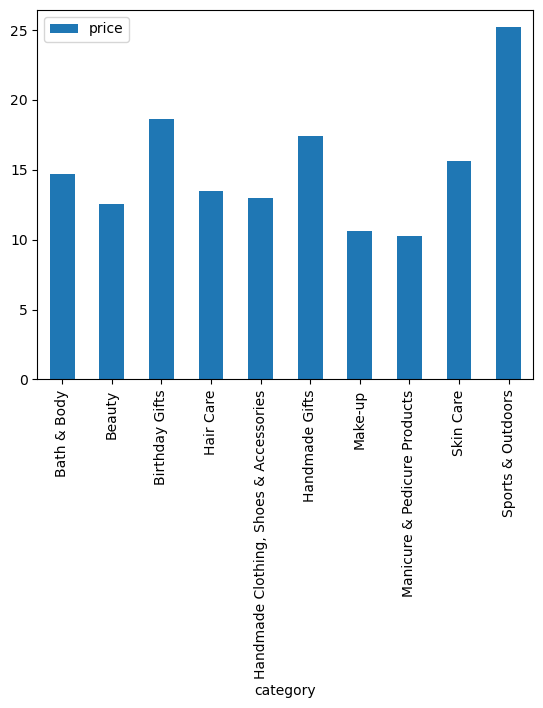

In [ ]:

top_10_avg.plot(kind="bar")

# sports & outdoors has the highest avg price

4. Box Plots:

- Visualize the distribution of product ratings based on their category using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
- Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

In [52]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [60]:
top_10_rating = df[df["category"].isin(count.index)].groupby("category")[["stars"]].mean()
top_10_rating


,stars
category,
Bath & Body,3.985517
Beauty,4.325799
Birthday Gifts,1.960664
Hair Care,4.148123
"Handmade Clothing, Shoes & Accessories",1.072436
Handmade Gifts,2.513790
Make-up,3.806689
Manicure & Pedicure Products,3.740542
Skin Care,4.141063


In [ ]:
plt.figure(figsize=(16,8))
sns.violinplot(data=df_top_20, x="category", y="price")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

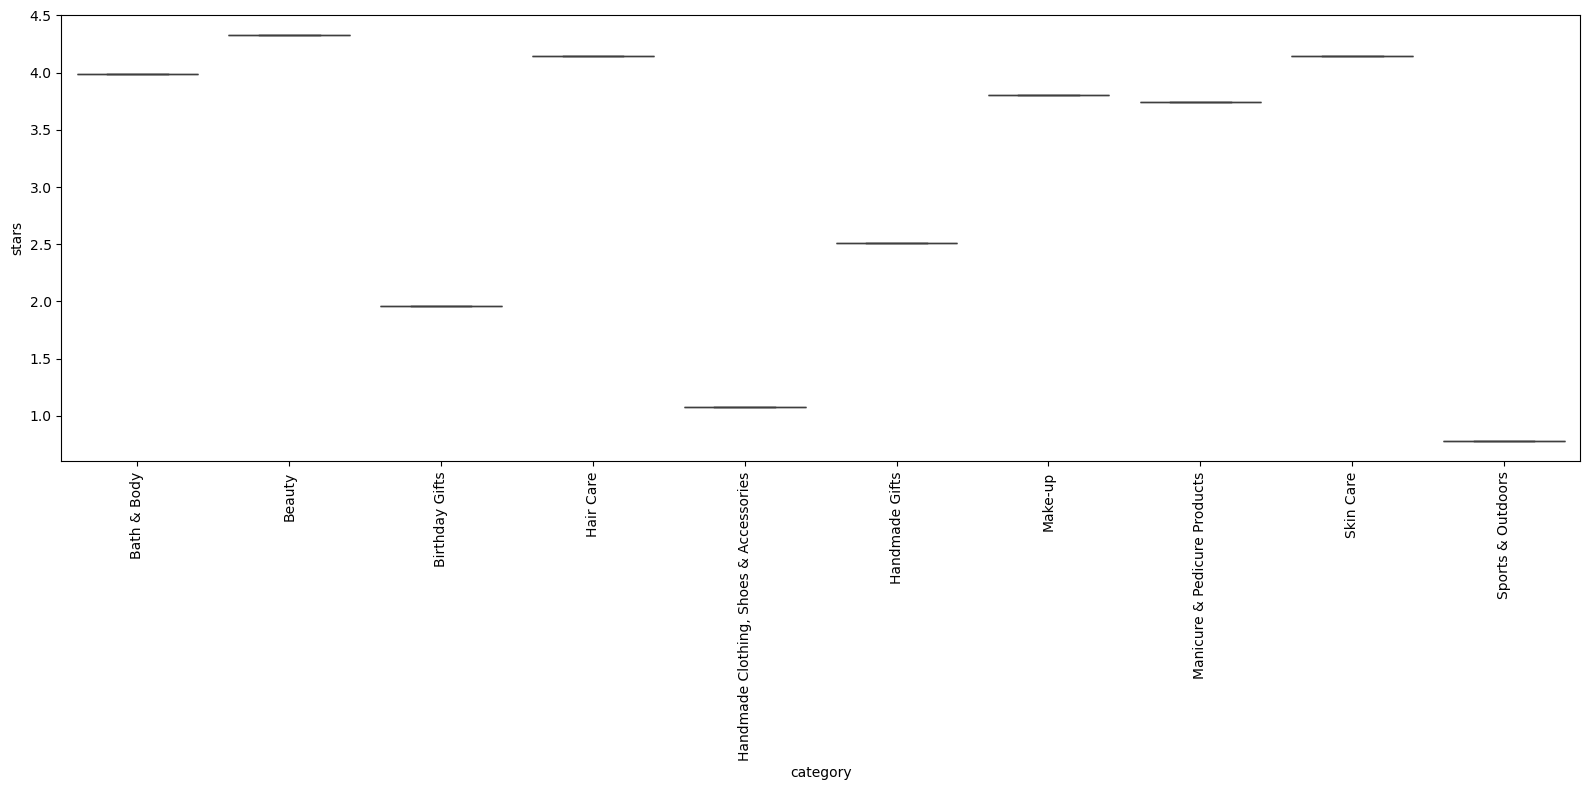

In [ ]:
plt.figure(figsize=(16,8))
sns.boxplot(data=top_10_rating, x="category", y="stars")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Beauty shows the highest median rating 